# Visualize Simulations

In [1]:
from kva import kva, set_storage
set_storage("./.kva")
run_id = kva.latest('run_id')
kva = kva.get(run_id=run_id)

In [2]:
kva.latest(["game", "players"], index=["step", "game_id"])

game               players
step game_id                                                           
0    145b4f06  4-Prisoners Dilemma with 2 players  [5c38e399, 44dbefd5]
     22a3afc3  4-Prisoners Dilemma with 2 players  [01ca7c35, c5b215c1]
     24133448  4-Prisoners Dilemma with 2 players  [04edb8c8, 1ed9aec9]
     24e7bba6  4-Prisoners Dilemma with 2 players  [1e6026ad, 001e78b6]
     2ba00ce3  4-Prisoners Dilemma with 2 players  [e7705d57, 14945021]
...                                           ...                   ...
12   c7bd0198  4-Prisoners Dilemma with 2 players  [0ff30300, c635ad10]
     d6fefb6e  4-Prisoners Dilemma with 2 players  [df47c5dd, c48e2fa6]
     e1651017  4-Prisoners Dilemma with 2 players  [40780162, 8466624d]
     fbc294e0  4-Prisoners Dilemma with 2 players  [2141b27c, 6628f053]
13   f7bb2407  4-Prisoners Dilemma with 2 players  [ff2bcde6, a2c919bd]

[655 rows x 2 columns]

### What happened in a random game of the last round?
- action / reward overview, e.g:
Round 1:
Alice (RandomAgent): Defect - +3
Bob (RandomAgent): Cooperate - -1

- transcr

In [4]:
game_id = kva.get(step=5).latest("game_id")
# Print game log
kva.get(game_id=game_id).latest(
    ['game', 'name', 'class', 'observation', 'action', 'add', 'total', 'game_id', 'step'],
    index=['round', 'agent_id'])

game  \
round agent_id                                       
0.0   6d5d0f06  4-Prisoners Dilemma with 2 players   
      8a14cd49  4-Prisoners Dilemma with 2 players   
1.0   6d5d0f06  4-Prisoners Dilemma with 2 players   
      8a14cd49  4-Prisoners Dilemma with 2 players   
2.0   6d5d0f06  4-Prisoners Dilemma with 2 players   
      8a14cd49  4-Prisoners Dilemma with 2 players   
3.0   6d5d0f06  4-Prisoners Dilemma with 2 players   
      8a14cd49  4-Prisoners Dilemma with 2 players   

                                                      observation  action  \
round agent_id                                                              
0.0   6d5d0f06  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
      8a14cd49  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
1.0   6d5d0f06  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
      8a14cd49  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
2.0   6d5d0f06  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
      8a14cd49  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
3.0   6d5d0f06  Ursula selected Defect and scored 0.0\nBob sel...  Defect   
      8a14cd49  Ursula selected Defect and scored 0.0\nBob sel...  Defect   

                add  total   game_id  step  
round agent_id                              
0.0   6d5d0f06  0.0    2.0  927f30ba     5  
      8a14cd49  0.0    1.0  927f30ba     5  
1.0   6d5d0f06  0.0    2.0  927f30ba     5  
      8a14cd49  0.0    1.0  927f30ba     5  
2.0   6d5d0f06  0.0    2.0  927f30ba     5  
      8a14cd49  0.0    1.0  927f30ba     5  
3.0   6d5d0f06  0.0    2.0  927f30ba     5  
      8a14cd49  0.0    1.0  927f30ba     5

# Plot agent distribution

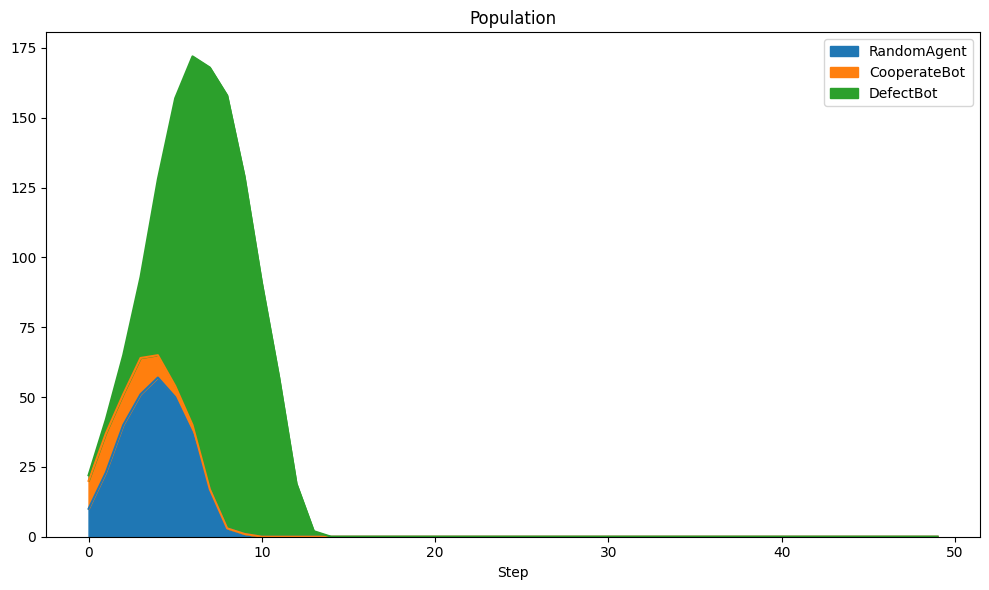

In [9]:
from matplotlib import pyplot as plt
import pandas as pd

df = kva.latest("population", index=["step"])

# Make a larger figure with higher resolution
fig = plt.figure(figsize=(10, 6), dpi=100)

df_unpacked = pd.json_normalize(df['population'])
df_result = pd.concat([df.drop('population', axis=1), df_unpacked], axis=1)[df['population'].iloc[0].keys()]

df_result.plot(kind='area', stacked=True, ax=plt.gca())
plt.title('Population')
plt.xlabel('Step')
plt.tight_layout()
plt.savefig('population2.png')